In [1]:
!pip install stim
!pip install pymatching
!pip install torch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
# If CUDA is available, show more details
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("PyTorch is using CPU only")

CUDA version: 13.0
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 5070 Ti
Current device: 0


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def surface_code_circuit(p, d): # physical error rate, distance
  return stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,
    distance=d,
    after_clifford_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
    before_round_data_depolarization=p)

def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
  # Sample the circuit.
  sampler = circuit.compile_detector_sampler()
  detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

  # Configure a decoder using the circuit.
  detector_error_model = circuit.detector_error_model(decompose_errors=True)
  matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

  # Run the decoder.
  predictions = matcher.decode_batch(detection_events)

  # basically compare predictions with observable_flips (what we should have measured)

  # Count the mistakes.
  num_errors = 0
  for shot in range(num_shots):
    actual_for_shot = observable_flips[shot]
    predicted_for_shot = predictions[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
  return num_errors

def ler_mwpm(p, d): # logical error rate, minimum weight perfect matching
  num_shots = 100000
  circuit = surface_code_circuit(p, d)
  num_errors = count_logical_errors(circuit, num_shots)

  return num_errors / num_shots

def plot_mwpm():
  num_shots = 100000
  for d in [3, 5, 7]:
    xs = []
    ys = []
    yerrs = []
    for noise in np.linspace(0.001, 0.008, 8):
      ler = ler_mwpm(noise, d)
      xs.append(noise)
      ys.append(ler)
      yerrs.append(np.sqrt(ler * (1 - ler) / num_shots))
    plt.errorbar(xs, ys, yerr=yerrs, fmt='o-', label="d=" + str(d), capsize=3)
  plt.loglog()
  plt.xlabel("physical error rate")
  plt.ylabel("logical error rate per shot")
  plt.legend()
  plt.show()


after_clifford: after every operation e.g. H gate, you will apply X, Y, Z with probability p/3 each <br/>
after_reset_flip: after you do a reset (you think you're resetted to 0 but reset to 1 with probability p) <br/>
before_measure_flip: you should measuring a 0 but with p you're measuring a 1 <br/>
before_round_data_depolarization: we apply the same general error - errors no operation (interaction with the environment - decohere) - idling error

In [6]:
#  plot_mwpm()

In [7]:
# do we need to train a model for each physical error rate or train at one physical error rate
# and then extrapolate at different physical error rates

# extrapolating distance: more difficult input shape
# evaluate the inference speed of the model
# data for distances

## Model Training

#### Definitions

In [8]:
from tqdm.auto import *
from torch import nn

def build_decoder(num_input):
  decoder = nn.Sequential(
    nn.Linear(num_input, 256),
    nn.SiLU(),
    nn.Linear(256, 512),
    nn.SiLU(),
    nn.Linear(512, 1024),
    nn.SiLU(),
    nn.Linear(1024, 1),
    nn.Sigmoid()
  ).to(device)
  loss_fn = nn.BCELoss() # inverse of accuracy

  # Create optimizer - if this fails with _utils error, run diagnostic cells above and reinstall PyTorch
  optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3) # tells you how to train
  # important here is lr, it cannot be too high, you are going to start missing out features, cannot be too slow, you are going to take forever
  return decoder, loss_fn, optimizer

def train_loop(measurements, flips, *, decoder, optimizer, loss_fn, train_size, bs=200):
  decoder.train()
  running_avg = 0
  with trange(train_size//bs) as pbar:
    for batch in pbar:
      X = measurements[batch*bs:(batch+1)*bs]
      y = flips[batch*bs:(batch+1)*bs][:,None]
      #pred = decoder(X.reshape((-1, 5*12)))
      pred = decoder(X)
      loss = loss_fn(pred, y)
      acc = torch.mean(((pred>0.5) == y).float())
      running_avg = acc * 0.01 + running_avg*0.99 if running_avg != 0 else acc
      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      if batch % 100 == 0:
        pbar.set_description(f'{running_avg:>4f} {loss:.4f}')

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Training

goals:
1. train neural network for distance 5 and 7 and see the train size required to beat MWMP
2. see if models can extrapolate and have similar performance for different physical error rates

Seeing whether you can train higher distance models and the problem if you cannot

In [9]:
def evaluate_model(decoder, circuit, test_size=10000):
    """Evaluate decoder accuracy on fresh test data"""
    sampler = circuit.compile_detector_sampler()
    detections, flips = sampler.sample(shots=test_size, separate_observables=True)
    detections = torch.Tensor(detections.astype(int) * 2 - 1).to(device)
    flips = torch.Tensor(flips.astype(int).flatten()).to(device)

    decoder.eval()
    with torch.no_grad():
        pred = decoder(detections)
        accuracy = torch.mean(((pred > 0.5).flatten() == flips).float()).item()
    return accuracy

In [10]:
import gc

p = 0.005
results = {}
CHUNK_SIZE = 10**7  # Max samples to load at once

for d in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"Distance {d}")
    print(f"{'='*50}")
    
    mwpm_accuracy = 1 - ler_mwpm(p, d)
    print(f"MWPM accuracy to beat: {mwpm_accuracy:.6f}")
    
    train_size = 100
    max_train_size = 10**8
    beat_mwpm = False
    circuit = surface_code_circuit(p, d)
    sample_detections, _ = circuit.compile_detector_sampler().sample(1, separate_observables=True)
    num_input = sample_detections.shape[1]
    
    while train_size <= max_train_size and not beat_mwpm:
        print(f"\nTrying train_size = {train_size:,}")
        
        # Build fresh model for this train_size
        decoder, loss_fn, optimizer = build_decoder(num_input)
        
        # Train in chunks
        samples_trained = 0
        num_chunks = max(1, train_size // CHUNK_SIZE)
        samples_per_chunk = min(train_size, CHUNK_SIZE)
        
        for chunk_idx in range(num_chunks):
            # Handle remainder for last chunk
            current_chunk_size = min(samples_per_chunk, train_size - samples_trained)
            print(f"  Chunk {chunk_idx+1}/{num_chunks}: {current_chunk_size:,} samples")
            
            # Generate chunk data
            sampler = circuit.compile_detector_sampler()
            detections, flips = sampler.sample(shots=current_chunk_size, separate_observables=True)
            detections = torch.Tensor(detections.astype(int) * 2 - 1).to(device)
            flips = torch.Tensor(flips.astype(int).flatten()).to(device)
            
            # Train on this chunk (model retains learning)
            train_loop(detections, flips, decoder=decoder, optimizer=optimizer,
                       loss_fn=loss_fn, train_size=current_chunk_size, 
                       bs=min(256, current_chunk_size))
            
            samples_trained += current_chunk_size
            
            # Clear chunk data from memory
            del detections, flips, sampler
            gc.collect()
            torch.cuda.empty_cache()
        
        # Evaluate after all chunks
        nn_accuracy = evaluate_model(decoder, circuit)
        print(f"NN accuracy: {nn_accuracy:.6f} vs MWPM: {mwpm_accuracy:.6f}")
        
        if nn_accuracy > mwpm_accuracy:
            print(f"SUCCESS: NN beats MWPM at train_size = {train_size:,}")
            results[d] = train_size
            beat_mwpm = True
        else:
            train_size *= 10
        
        # Clear model before trying next train_size
        del decoder, loss_fn, optimizer
        gc.collect()
        torch.cuda.empty_cache()
    
    if not beat_mwpm:
        print(f"Did not beat MWPM within max train_size")
        results[d] = None

print(f"\n{'='*50}")
print("RESULTS SUMMARY")  
print(f"{'='*50}")
for d, size in results.items():
    print(f"Distance {d}: {'train_size = ' + f'{size:,}' if size else 'Did not beat MWPM'}")



Distance 3
MWPM accuracy to beat: 0.982750

Trying train_size = 100
  Chunk 1/1: 100 samples


0.260000 0.6929: 100%|██████████| 1/1 [00:00<00:00,  5.52it/s]


NN accuracy: 0.897300 vs MWPM: 0.982750

Trying train_size = 1,000
  Chunk 1/1: 1,000 samples


0.113281 0.7051: 100%|██████████| 3/3 [00:00<00:00, 122.20it/s]


NN accuracy: 0.893300 vs MWPM: 0.982750

Trying train_size = 10,000
  Chunk 1/1: 10,000 samples


...

  Chunk 9/10: 10,000,000 samples


0.898829 0.2104: 100%|██████████| 39062/39062 [01:05<00:00, 597.88it/s]


  Chunk 10/10: 10,000,000 samples


0.902057 0.2376: 100%|██████████| 39062/39062 [01:15<00:00, 519.84it/s]


NN accuracy: 0.905400 vs MWPM: 0.990640
Did not beat MWPM within max train_size

RESULTS SUMMARY
Distance 3: train_size = 10,000,000
Distance 5: Did not beat MWPM
Distance 7: Did not beat MWPM


In [12]:
results

{3: 10000000, 5: None, 7: None}

#### NN Decoder Extrapolation Experiment

Train models for distances 3, 5, 7 at p=0.05, then test extrapolation to p=[0.001, 0.01]

In [16]:
# Train models for d=3, 5, 7 at p=0.005 with train_size=10^7
# Or load from saved files if they exist
import gc
import os

train_p = 0.005
train_size = 10**7
trained_models = {}

for d in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"Distance {d}")
    print(f"{'='*50}")
    
    model_path = f"nn_decoder_d{d}_p{train_p}.pt"
    
    # Get num_input for this distance
    circuit = surface_code_circuit(train_p, d)
    sample_detections, _ = circuit.compile_detector_sampler().sample(1, separate_observables=True)
    num_input = sample_detections.shape[1]
    
    # Check if saved model exists
    if os.path.exists(model_path):
        print(f"Loading saved model from {model_path}...")
        decoder, _, _ = build_decoder(num_input)
        decoder.load_state_dict(torch.load(model_path, weights_only=True))
        decoder.eval()
        print(f"Model for distance {d} loaded successfully.")
    else:
        print(f"No saved model found. Training new model...")
        print(f"Number of input features: {num_input}")
        
        # Build model
        decoder, loss_fn, optimizer = build_decoder(num_input)
        
        # Generate training data
        print(f"Generating {train_size:,} training samples...")
        sampler = circuit.compile_detector_sampler()
        detections, flips = sampler.sample(shots=train_size, separate_observables=True)
        detections = torch.Tensor(detections.astype(int) * 2 - 1).to(device)
        flips = torch.Tensor(flips.astype(int).flatten()).to(device)
        
        # Train the model (same approach as cell 15)
        print("Training...")
        train_loop(detections, flips, decoder=decoder, optimizer=optimizer,
                   loss_fn=loss_fn, train_size=train_size, 
                   bs=min(256, train_size))
        
        # Save the trained model
        torch.save(decoder.state_dict(), model_path)
        print(f"Model saved to {model_path}")
        
        # Clean up training data
        del detections, flips, sampler, loss_fn, optimizer
        gc.collect()
        torch.cuda.empty_cache()
        
        print(f"Model for distance {d} trained and stored.")
    
    trained_models[d] = decoder

print(f"\n{'='*50}")
print("All models ready!")
print(f"{'='*50}")



Distance 3
No saved model found. Training new model...
Number of input features: 24
Generating 10,000,000 training samples...
Training...


0.984483 0.0175: 100%|██████████| 39062/39062 [01:15<00:00, 515.77it/s]


Model saved to nn_decoder_d3_p0.005.pt
Model for distance 3 trained and stored.

Distance 5
No saved model found. Training new model...
Number of input features: 120
Generating 10,000,000 training samples...
Training...


0.974803 0.0596: 100%|██████████| 39062/39062 [01:18<00:00, 495.75it/s]


Model saved to nn_decoder_d5_p0.005.pt
Model for distance 5 trained and stored.

Distance 7
No saved model found. Training new model...
Number of input features: 336
Generating 10,000,000 training samples...
Training...


0.855954 0.3117: 100%|██████████| 39062/39062 [01:23<00:00, 466.17it/s]


Model saved to nn_decoder_d7_p0.005.pt
Model for distance 7 trained and stored.

All models ready!


In [17]:
def ler_nn(decoder, p, d, num_shots=100000):
    """Compute logical error rate for NN decoder at given physical error rate"""
    circuit = surface_code_circuit(p, d)
    sampler = circuit.compile_detector_sampler()
    detections, flips = sampler.sample(num_shots, separate_observables=True)
    detections = torch.Tensor(detections.astype(int) * 2 - 1).to(device)
    
    decoder.eval()
    with torch.no_grad():
        pred = decoder(detections)
        errors = ((pred > 0.5).flatten().cpu().numpy() != flips.flatten())
    return errors.mean()


In [18]:
# Test each model on p = 0.001 to p = 0.01
num_shots = 100000
test_p_values = np.linspace(0.001, 0.01, 10)
nn_results = {d: {'p': [], 'ler': [], 'yerr': []} for d in [3, 5, 7]}

for d in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"Testing model for distance {d}")
    print(f"{'='*50}")
    
    decoder = trained_models[d]
    
    for p in test_p_values:
        ler = ler_nn(decoder, p, d, num_shots=num_shots)
        yerr = np.sqrt(ler * (1 - ler) / num_shots)
        
        nn_results[d]['p'].append(p)
        nn_results[d]['ler'].append(ler)
        nn_results[d]['yerr'].append(yerr)
        
        print(f"  p = {p:.4f}: LER = {ler:.6f}")

print("\nTesting complete!")



Testing model for distance 3
  p = 0.0010: LER = 0.000690
  p = 0.0020: LER = 0.002440
  p = 0.0030: LER = 0.005710
  p = 0.0040: LER = 0.009740
  p = 0.0050: LER = 0.016100
  p = 0.0060: LER = 0.021850
  p = 0.0070: LER = 0.029270
  p = 0.0080: LER = 0.038290
  p = 0.0090: LER = 0.046830
  p = 0.0100: LER = 0.055960

Testing model for distance 5
  p = 0.0010: LER = 0.000280
  p = 0.0020: LER = 0.001660
  p = 0.0030: LER = 0.005860
  p = 0.0040: LER = 0.012760
  p = 0.0050: LER = 0.023800
  p = 0.0060: LER = 0.040050
  p = 0.0070: LER = 0.059060
  p = 0.0080: LER = 0.082090
  p = 0.0090: LER = 0.108760
  p = 0.0100: LER = 0.137600

Testing model for distance 7
  p = 0.0010: LER = 0.005810
  p = 0.0020: LER = 0.025900
  p = 0.0030: LER = 0.055270
  p = 0.0040: LER = 0.095220
  p = 0.0050: LER = 0.140160
  p = 0.0060: LER = 0.188720
  p = 0.0070: LER = 0.235940
  p = 0.0080: LER = 0.277920
  p = 0.0090: LER = 0.319610
  p = 0.0100: LER = 0.353930

Testing complete!


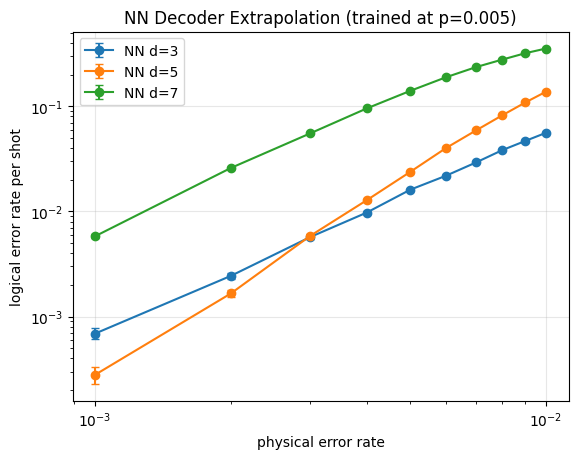

In [19]:
def plot_nn_extrapolation(nn_results, num_shots=100000):
    """Plot NN decoder LER vs physical error rate, similar to plot_mwpm()"""
    for d, data in nn_results.items():
        plt.errorbar(data['p'], data['ler'], yerr=data['yerr'], 
                     fmt='o-', label=f"NN d={d}", capsize=3)
    plt.loglog()
    plt.xlabel("physical error rate")
    plt.ylabel("logical error rate per shot")
    plt.title(f"NN Decoder Extrapolation (trained at p={train_p})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot the results
plot_nn_extrapolation(nn_results)


In [20]:
# Save results for reproducibility
import pickle

with open('nn_extrapolation_results.pkl', 'wb') as f:
    pickle.dump({
        'nn_results': nn_results,
        'train_p': train_p,
        'train_size': train_size,
        'test_p_values': test_p_values.tolist(),
        'num_shots': num_shots
    }, f)

print("Results saved to nn_extrapolation_results.pkl")


Results saved to nn_extrapolation_results.pkl


In [ ]:
# Display results summary
print(f"{'='*60}")
print(f"NN Decoder Extrapolation Results Summary")
print(f"Training: p={train_p}, train_size={train_size:,}")
print(f"{'='*60}")
print(f"\n{'p':<10} {'d=3 LER':<15} {'d=5 LER':<15} {'d=7 LER':<15}")
print("-" * 55)

for i, p in enumerate(test_p_values):
    ler3 = nn_results[3]['ler'][i]
    ler5 = nn_results[5]['ler'][i]
    ler7 = nn_results[7]['ler'][i]
    print(f"{p:<10.4f} {ler3:<15.6f} {ler5:<15.6f} {ler7:<15.6f}")

print(f"\n{'='*60}")


NN Decoder Extrapolation Results Summary


NameError: name 'train_p' is not defined